In [1]:
import numpy as np
import matplotlib as mpl
mpl.rcParams['figure.dpi']= 100
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import axes3d    
import matplotlib.dates as mdates
import matplotlib.gridspec as gs
import pandas as pd
import seaborn as sns

import sklearn
from sklearn.metrics import roc_curve, roc_auc_score, log_loss, accuracy_score, precision_recall_curve,\
                            average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import xgboost as xgb

# Import Data and Check Features

In [2]:
data = pd.read_csv('Task 3 and 4_Loan_Data.csv')

In [3]:
data

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0
...,...,...,...,...,...,...,...,...
9995,3972488,0,3033.647103,2553.733144,42691.62787,5,697,0
9996,6184073,1,4146.239304,5458.163525,79969.50521,8,615,0
9997,6694516,2,3088.223727,4813.090925,38192.67591,5,596,0
9998,3942961,0,3288.901666,1043.099660,50929.37206,2,647,0


Numebr of defaulted is 1851. Number of no-default is 8149.


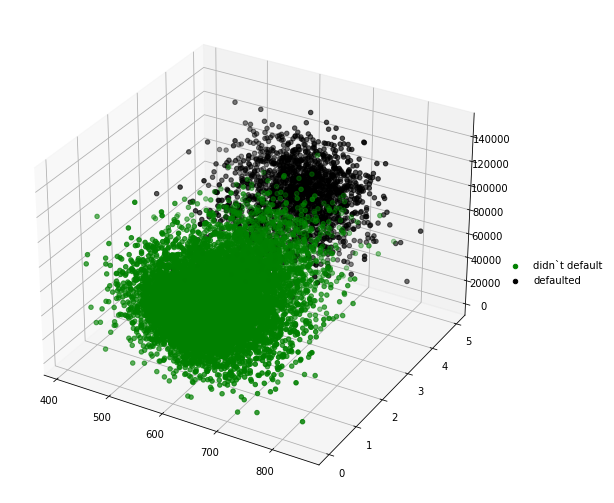

In [4]:
defaulted = data[data['default']==1]
no_default = data[data['default']==0]

print(f"Numebr of defaulted is {len(defaulted)}. Number of no-default is {len(no_default)}.")

x_d = defaulted['fico_score']
y_d = defaulted['credit_lines_outstanding']
z_d = defaulted['income']

x_nd = no_default['fico_score']
y_nd = no_default['credit_lines_outstanding']
z_nd = no_default['income']


fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(projection='3d')

ax.scatter(x_nd, y_nd, z_nd, label='didn`t default' ,color='g')
ax.scatter(x_d, y_d, z_d, label='defaulted',color='k')

ax.legend(bbox_to_anchor=(1, 0.5), loc='upper left', frameon=False)
plt.show()


Just from looking at the data, there is a somewhat clear separation between defaulting and non-defaulting data! However, there is an overlap region that will maybe give us some trouble. Let's see what our models can do!

Since we obviously do not know whether they will default on the loans in this set, we will have to leverage the 'default' column as our classification indicator. Further, since we also do not know what each customer's features were (creditlines, loan_amt, fico_score, etc) at the time of default, we can only use the information we have now.

### Splitting data

In [5]:
Y = data['default']
X = data.drop(columns=['customer_id','default'])

# Let's use the last quarter of data for validation
split_ind = 3*( len(data)-1 )//4
Y_train = Y[:split_ind]
X_train = X[:split_ind]
Y_valid = Y[split_ind:]
X_valid = X[split_ind:]

# Logistic Regression

In [6]:
BT = xgb.XGBClassifier(
    objective="binary:logistic",
    tree_method="hist",
    learning_rate=0.05,
    n_estimators=2000,
    max_depth=6
)

BT.set_params(eval_metric=["auc","logloss"], early_stopping_rounds=50)
BT.fit(X_train, Y_train, eval_set=[(X_valid, Y_valid)], verbose=True)


[0]	validation_0-auc:0.99853	validation_0-logloss:0.64548
[1]	validation_0-auc:0.99847	validation_0-logloss:0.60229
[2]	validation_0-auc:0.99846	validation_0-logloss:0.56303
[3]	validation_0-auc:0.99846	validation_0-logloss:0.52720
[4]	validation_0-auc:0.99846	validation_0-logloss:0.49439
[5]	validation_0-auc:0.99923	validation_0-logloss:0.46416
[6]	validation_0-auc:0.99927	validation_0-logloss:0.43629
[7]	validation_0-auc:0.99944	validation_0-logloss:0.41046
[8]	validation_0-auc:0.99944	validation_0-logloss:0.38654
[9]	validation_0-auc:0.99944	validation_0-logloss:0.36439
[10]	validation_0-auc:0.99945	validation_0-logloss:0.34378
[11]	validation_0-auc:0.99945	validation_0-logloss:0.32463
[12]	validation_0-auc:0.99946	validation_0-logloss:0.30672
[13]	validation_0-auc:0.99951	validation_0-logloss:0.29008
[14]	validation_0-auc:0.99956	validation_0-logloss:0.27446
[15]	validation_0-auc:0.99955	validation_0-logloss:0.25991
[16]	validation_0-auc:0.99956	validation_0-logloss:0.24623
[17]	va

[139]	validation_0-auc:0.99983	validation_0-logloss:0.01273
[140]	validation_0-auc:0.99983	validation_0-logloss:0.01266
[141]	validation_0-auc:0.99983	validation_0-logloss:0.01259
[142]	validation_0-auc:0.99983	validation_0-logloss:0.01257
[143]	validation_0-auc:0.99983	validation_0-logloss:0.01256
[144]	validation_0-auc:0.99983	validation_0-logloss:0.01247
[145]	validation_0-auc:0.99983	validation_0-logloss:0.01245
[146]	validation_0-auc:0.99983	validation_0-logloss:0.01236
[147]	validation_0-auc:0.99983	validation_0-logloss:0.01233
[148]	validation_0-auc:0.99983	validation_0-logloss:0.01233
[149]	validation_0-auc:0.99983	validation_0-logloss:0.01231
[150]	validation_0-auc:0.99983	validation_0-logloss:0.01230
[151]	validation_0-auc:0.99983	validation_0-logloss:0.01229
[152]	validation_0-auc:0.99983	validation_0-logloss:0.01225
[153]	validation_0-auc:0.99983	validation_0-logloss:0.01217
[154]	validation_0-auc:0.99983	validation_0-logloss:0.01217
[155]	validation_0-auc:0.99983	validatio

[276]	validation_0-auc:0.99989	validation_0-logloss:0.01041
[277]	validation_0-auc:0.99988	validation_0-logloss:0.01042
[278]	validation_0-auc:0.99989	validation_0-logloss:0.01039
[279]	validation_0-auc:0.99989	validation_0-logloss:0.01039
[280]	validation_0-auc:0.99989	validation_0-logloss:0.01039
[281]	validation_0-auc:0.99988	validation_0-logloss:0.01037
[282]	validation_0-auc:0.99988	validation_0-logloss:0.01038
[283]	validation_0-auc:0.99988	validation_0-logloss:0.01035
[284]	validation_0-auc:0.99988	validation_0-logloss:0.01034
[285]	validation_0-auc:0.99988	validation_0-logloss:0.01035
[286]	validation_0-auc:0.99988	validation_0-logloss:0.01033
[287]	validation_0-auc:0.99988	validation_0-logloss:0.01033
[288]	validation_0-auc:0.99988	validation_0-logloss:0.01033
[289]	validation_0-auc:0.99988	validation_0-logloss:0.01031
[290]	validation_0-auc:0.99989	validation_0-logloss:0.01028
[291]	validation_0-auc:0.99989	validation_0-logloss:0.01028
[292]	validation_0-auc:0.99989	validatio

[413]	validation_0-auc:0.99990	validation_0-logloss:0.00996
[414]	validation_0-auc:0.99990	validation_0-logloss:0.00997
[415]	validation_0-auc:0.99990	validation_0-logloss:0.00996
[416]	validation_0-auc:0.99990	validation_0-logloss:0.00995
[417]	validation_0-auc:0.99990	validation_0-logloss:0.00994
[418]	validation_0-auc:0.99990	validation_0-logloss:0.00995
[419]	validation_0-auc:0.99990	validation_0-logloss:0.00995
[420]	validation_0-auc:0.99990	validation_0-logloss:0.00996
[421]	validation_0-auc:0.99990	validation_0-logloss:0.00997
[422]	validation_0-auc:0.99990	validation_0-logloss:0.00997
[423]	validation_0-auc:0.99990	validation_0-logloss:0.00998
[424]	validation_0-auc:0.99990	validation_0-logloss:0.00997
[425]	validation_0-auc:0.99990	validation_0-logloss:0.00995
[426]	validation_0-auc:0.99990	validation_0-logloss:0.00995
[427]	validation_0-auc:0.99990	validation_0-logloss:0.00995
[428]	validation_0-auc:0.99990	validation_0-logloss:0.00995
[429]	validation_0-auc:0.99990	validatio

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric=['auc', 'logloss'],
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=2000, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=None, ...)

Training Set:
AUC: 1.0
LogLoss: 0.0012814349564935622
PR AUC: 1.0
Brier  : 0.00011423171761273053
----------------------------------------------------------------------------------------------------
Validation Set:
AUC: 0.9999047788329694
LogLoss: 0.009893734026233678
PR AUC: 0.9995808141952589
Brier  : 0.002998628233026496
----------------------------------------------------------------------------------------------------


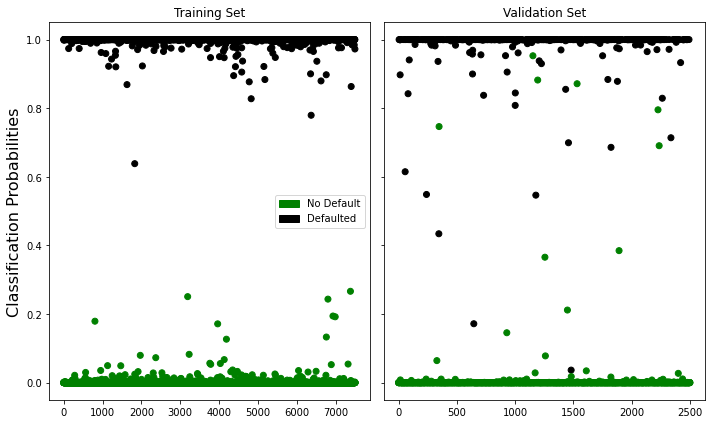

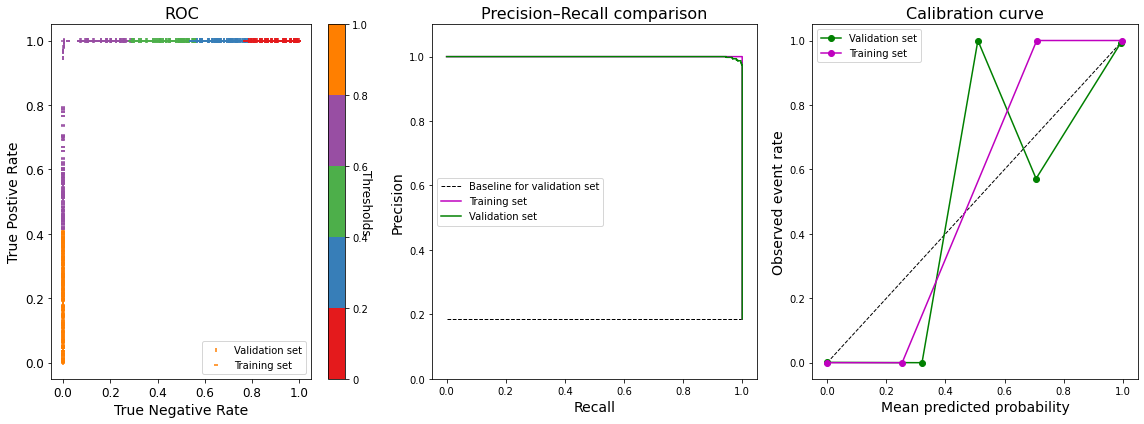

In [7]:
proba_valid_BT = BT.predict_proba(X_valid)[:, 1]
proba_train_BT = BT.predict_proba(X_train)[:, 1]

print("Training Set:")
print("AUC:", roc_auc_score(Y_train, proba_train_BT))
print("LogLoss:", log_loss(Y_train, proba_train_BT))
print("PR AUC:", average_precision_score(Y_train, proba_train_BT))
print("Brier  :", brier_score_loss(Y_train, proba_train_BT))
print("-----"*20)
print("Validation Set:")
print("AUC:", roc_auc_score(Y_valid, proba_valid_BT))
print("LogLoss:", log_loss(Y_valid, proba_valid_BT))
print("PR AUC:", average_precision_score(Y_valid, proba_valid_BT))
print("Brier  :", brier_score_loss(Y_valid, proba_valid_BT))
print("-----"*20)


# Classification Probabilities:
fig1, (axT,axV) = plt.subplots(1,2,figsize=(10,6), sharey=True)
fig2, (axROC,axPR,axC) = plt.subplots(1,3, figsize=(16,6))
valid_color = ['k' if y==1 else 'g' for y in Y_valid]
axV.set_title("Validation Set",fontsize=12)
axV.scatter(range(len(proba_valid_BT)), proba_valid_BT, color=valid_color)

train_color = ['k' if y==1 else 'g' for y in Y_train]
axT.set_ylabel("Classification Probabilities",fontsize=16)
axT.set_title("Training Set",fontsize=12)
axT.scatter(range(len(proba_train_BT)), proba_train_BT, color=train_color)

gr = mpatches.Patch(color='g', label='No Default')
k = mpatches.Patch(color='k', label='Defaulted')
axT.legend(handles=[gr,k])

# ROC:
fprV, tprV, threshV = roc_curve(Y_valid,proba_valid_BT)
threshV[0] = 1
boundV = np.quantile(threshV, [0, .2, .4, .6, .8, 1.0])
norm = mcolors.BoundaryNorm(boundaries=boundV, ncolors=5, clip=True)
sc = axROC.scatter(fprV, tprV, c=threshV, cmap="Set1", norm=norm, s=20, marker='|', label='Validation set')
cb = plt.colorbar(sc, ax=axROC)
cb.set_label("Threshold bins")
cb.ax.set_yticklabels([0, .2, .4, .6, .8, 1.0])
cb.set_label('Thresholds', rotation=270,fontsize=12)

fprT, tprT, threshT = roc_curve(Y_train,proba_train_BT)
threshT[0] = 1
boundT = np.quantile(threshV, [0, .2, .4, .6, .8, 1.0])
norm = mcolors.BoundaryNorm(boundaries=boundT, ncolors=5, clip=True)
sc = axROC.scatter(fprT, tprT, c=threshT, cmap="Set1", norm=norm, s=16, marker='_',label='Training set')

axROC.set_title("ROC",fontsize=16)
axROC.set_ylabel("True Postive Rate",fontsize=14)
axROC.set_xlabel("True Negative Rate",fontsize=14)
axROC.tick_params(axis='both', which='major', labelsize=12)
axROC.legend()

# Precision Recall Curve
precV, recV, thrV = precision_recall_curve(Y_valid, proba_valid_BT)
precT, recT, thrT = precision_recall_curve(Y_train, proba_train_BT)
pos_rate = (np.isclose(Y_valid,1)).mean()
axPR.hlines(pos_rate, 0, 1, linestyles="--",color='k', linewidth=1, label="Baseline for validation set")
axPR.step(recT, precT, where="post", c='m', label='Training set')
axPR.step(recV, precV, where="post", c='g',label='Validation set')
axPR.set_xlabel("Recall",fontsize=14)
axPR.set_ylabel("Precision",fontsize=14)
axPR.set_title("Precision–Recall comparison",fontsize=16)
axPR.set_ylim((0,1.1))
axPR.legend(loc='center left')

# Calibration Curve
prob_true, prob_pred = calibration_curve(Y_valid, proba_valid_BT, n_bins=5)
prob_true_T, prob_pred_T = calibration_curve(Y_train, proba_train_BT, n_bins=5)
axC.plot([0,1],[0,1],"--", lw=1,c='k')
axC.plot(prob_pred, prob_true, marker="o", c='g', label="Validation set")
axC.plot(prob_pred_T, prob_true_T, marker="o", c='m', label="Training set")
axC.set_xlabel("Mean predicted probability", fontsize=14)
axC.set_ylabel("Observed event rate", fontsize=14)
axC.set_title("Calibration curve", fontsize=16)
axC.legend()


fig1.tight_layout()
fig2.tight_layout()
plt.show()

### Logistic Regression with trees (via xgBoost) is already not so bad.   
Calibration curve leaves a bit of room for improvement, with under and over predictions in the areas where the model is less sure about an input's class. However, this area also has the least amount of points as evidenced from the "Classification Probabilities" scatter plot.

# Random Forest

In [8]:
RF = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1,
    random_state=42,
    class_weight=None,
    verbose=False
)
RF.fit(X_train, Y_train)

RandomForestClassifier(min_samples_leaf=5, n_estimators=500, n_jobs=-1,
                       random_state=42, verbose=False)

Training Set:
AUC: 0.999949630450292
LogLoss: 0.017680105387311948
PR AUC: 0.9997809889874598
Brier  : 0.0035853297315211374
----------------------------------------------------------------------------------------------------
Validation Set:
AUC: 0.9998063836270378
LogLoss: 0.023501417202111987
PR AUC: 0.9991629575158125
Brier  : 0.005583598314617221
----------------------------------------------------------------------------------------------------


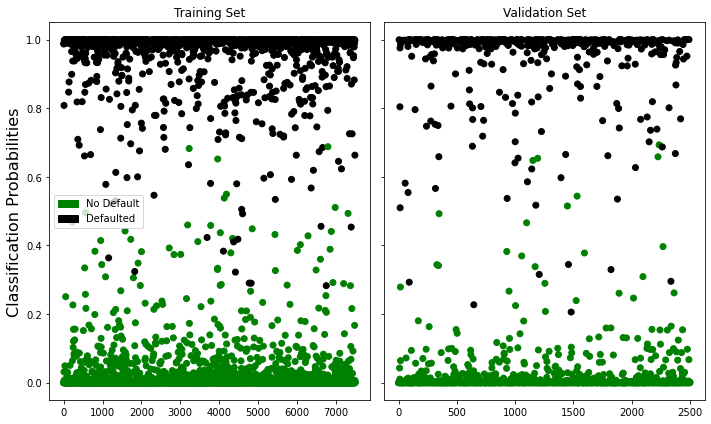

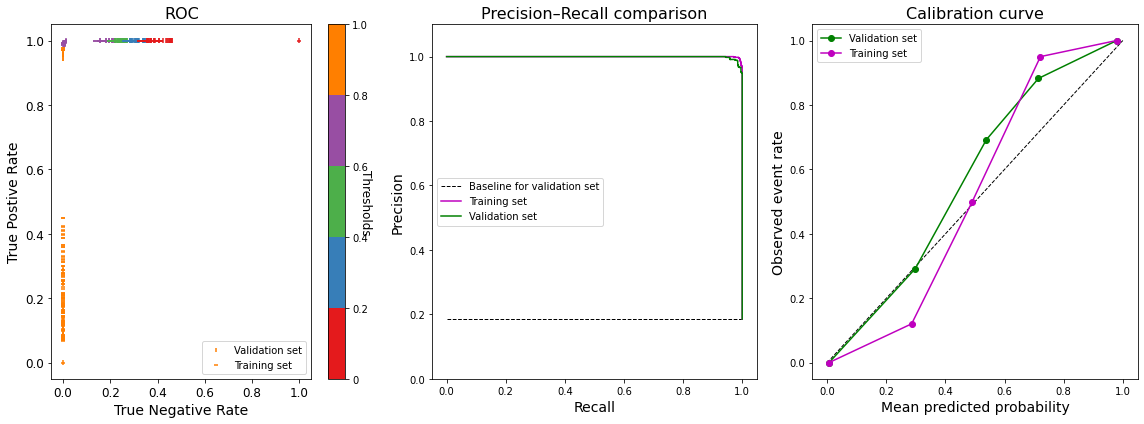

In [9]:
proba_valid_RF = RF.predict_proba(X_valid)[:, 1]
proba_train_RF = RF.predict_proba(X_train)[:, 1]

print("Training Set:")
print("AUC:", roc_auc_score(Y_train, proba_train_RF))
print("LogLoss:", log_loss(Y_train, proba_train_RF))
print("PR AUC:", average_precision_score(Y_train, proba_train_RF))
print("Brier  :", brier_score_loss(Y_train, proba_train_RF))
print("-----"*20)
print("Validation Set:")
print("AUC:", roc_auc_score(Y_valid, proba_valid_RF))
print("LogLoss:", log_loss(Y_valid, proba_valid_RF))
print("PR AUC:", average_precision_score(Y_valid, proba_valid_RF))
print("Brier  :", brier_score_loss(Y_valid, proba_valid_RF))
print("-----"*20)


# Classification Probabilities:
fig1, (axT,axV) = plt.subplots(1,2,figsize=(10,6), sharey=True)
fig2, (axROC,axPR,axC) = plt.subplots(1,3, figsize=(16,6))
valid_color = ['k' if y==1 else 'g' for y in Y_valid]
axV.set_title("Validation Set",fontsize=12)
axV.scatter(range(len(proba_valid_RF)), proba_valid_RF, color=valid_color)

train_color = ['k' if y==1 else 'g' for y in Y_train]
axT.set_ylabel("Classification Probabilities",fontsize=16)
axT.set_title("Training Set",fontsize=12)
axT.scatter(range(len(proba_train_RF)), proba_train_RF, color=train_color)

gr = mpatches.Patch(color='g', label='No Default')
k = mpatches.Patch(color='k', label='Defaulted')
axT.legend(handles=[gr,k])

# ROC:
fprV, tprV, threshV = roc_curve(Y_valid,proba_valid_RF)
threshV[0] = 1
boundV = np.quantile(threshV, [0, .2, .4, .6, .8, 1.0])
norm = mcolors.BoundaryNorm(boundaries=boundV, ncolors=5, clip=True)
sc = axROC.scatter(fprV, tprV, c=threshV, cmap="Set1", norm=norm, s=20, marker='|', label='Validation set')
cb = plt.colorbar(sc, ax=axROC)
cb.set_label("Threshold bins")
cb.ax.set_yticklabels([0, .2, .4, .6, .8, 1.0])
cb.set_label('Thresholds', rotation=270,fontsize=12)

fprT, tprT, threshT = roc_curve(Y_train,proba_train_RF)
threshT[0] = 1
boundT = np.quantile(threshV, [0, .2, .4, .6, .8, 1.0])
norm = mcolors.BoundaryNorm(boundaries=boundT, ncolors=5, clip=True)
sc = axROC.scatter(fprT, tprT, c=threshT, cmap="Set1", norm=norm, s=16, marker='_',label='Training set')

axROC.set_title("ROC",fontsize=16)
axROC.set_ylabel("True Postive Rate",fontsize=14)
axROC.set_xlabel("True Negative Rate",fontsize=14)
axROC.tick_params(axis='both', which='major', labelsize=12)
axROC.legend()

# Precision Recall Curve
precV, recV, thrV = precision_recall_curve(Y_valid, proba_valid_RF)
precT, recT, thrT = precision_recall_curve(Y_train, proba_train_RF)
pos_rate = (np.isclose(Y_valid,1)).mean()
axPR.hlines(pos_rate, 0, 1, linestyles="--",color='k', linewidth=1, label="Baseline for validation set")
axPR.step(recT, precT, where="post", c='m', label='Training set')
axPR.step(recV, precV, where="post", c='g',label='Validation set')
axPR.set_xlabel("Recall",fontsize=14)
axPR.set_ylabel("Precision",fontsize=14)
axPR.set_title("Precision–Recall comparison",fontsize=16)
axPR.set_ylim((0,1.1))
axPR.legend(loc='center left')

# Calibration Curve
prob_true, prob_pred = calibration_curve(Y_valid, proba_valid_RF, n_bins=5)
prob_true_T, prob_pred_T = calibration_curve(Y_train, proba_train_RF, n_bins=5)
axC.plot([0,1],[0,1],"--", lw=1,c='k')
axC.plot(prob_pred, prob_true, marker="o", c='g', label="Validation set")
axC.plot(prob_pred_T, prob_true_T, marker="o", c='m', label="Training set")
axC.set_xlabel("Mean predicted probability", fontsize=14)
axC.set_ylabel("Observed event rate", fontsize=14)
axC.set_title("Calibration curve", fontsize=16)
axC.legend()


fig1.tight_layout()
fig2.tight_layout()
plt.show()

### Random Forest also looks good!   
Brier score is a little bit worse for training and validation sets, but the calibration curve already starts to look a bit better in terms of over/under predicting. However, this may also be related to the slightly more diffuse spread of classification proobabilities through ntermediate probability values.

# Support Vector Machine

In [10]:
SVM = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf",
                C=1.0,
                gamma="scale",
                probability=True))
])
SVM.fit(X_train, Y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC(probability=True))])

Training Set:
AUC: 0.9999541129863314
LogLoss: 0.007844342126904486
PR AUC: 0.999799891631608
Brier  : 0.002169195677319009
----------------------------------------------------------------------------------------------------
Validation Set:
AUC: 0.99984447209385
LogLoss: 0.014141679844464726
PR AUC: 0.9993221043531633
Brier  : 0.004546526761774541
----------------------------------------------------------------------------------------------------


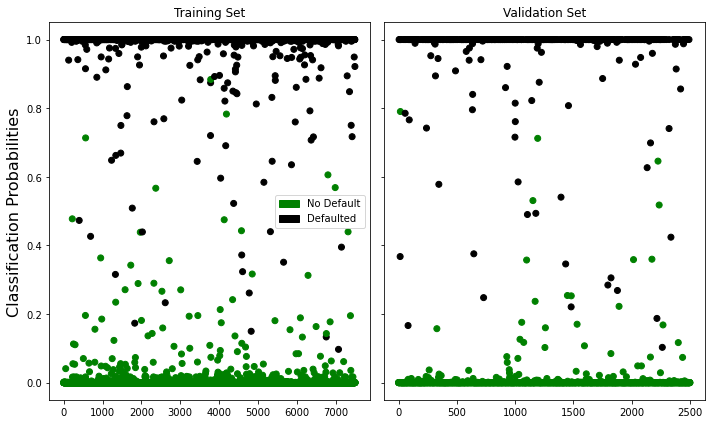

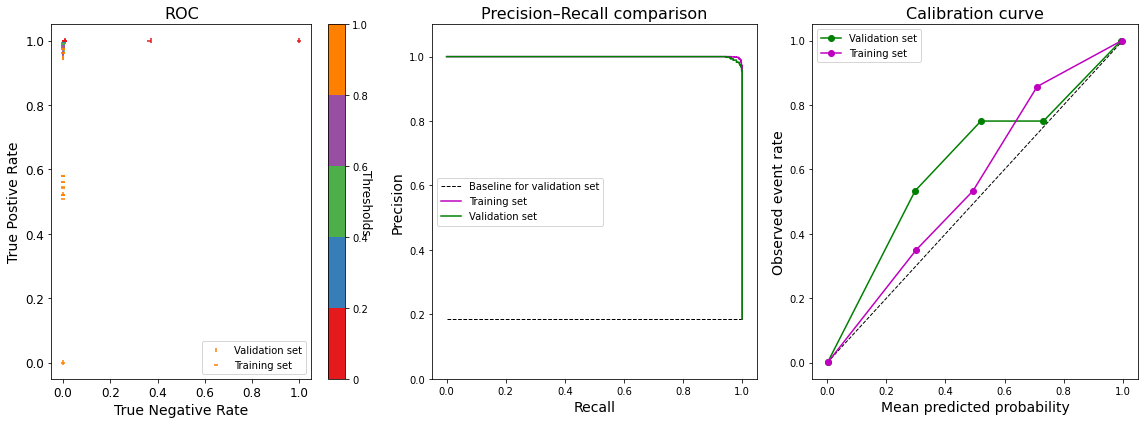

In [11]:
proba_valid_SVM = SVM.predict_proba(X_valid)[:, 1]
proba_train_SVM = SVM.predict_proba(X_train)[:, 1]

print("Training Set:")
print("AUC:", roc_auc_score(Y_train, proba_train_SVM))
print("LogLoss:", log_loss(Y_train, proba_train_SVM))
print("PR AUC:", average_precision_score(Y_train, proba_train_SVM))
print("Brier  :", brier_score_loss(Y_train, proba_train_SVM))
print("-----"*20)
print("Validation Set:")
print("AUC:", roc_auc_score(Y_valid, proba_valid_SVM))
print("LogLoss:", log_loss(Y_valid, proba_valid_SVM))
print("PR AUC:", average_precision_score(Y_valid, proba_valid_SVM))
print("Brier  :", brier_score_loss(Y_valid, proba_valid_SVM))
print("-----"*20)


# Classification Probabilities:
fig1, (axT,axV) = plt.subplots(1,2,figsize=(10,6), sharey=True)
fig2, (axROC,axPR,axC) = plt.subplots(1,3, figsize=(16,6))
valid_color = ['k' if y==1 else 'g' for y in Y_valid]
axV.set_title("Validation Set",fontsize=12)
axV.scatter(range(len(proba_valid_SVM)), proba_valid_SVM, color=valid_color)

train_color = ['k' if y==1 else 'g' for y in Y_train]
axT.set_ylabel("Classification Probabilities",fontsize=16)
axT.set_title("Training Set",fontsize=12)
axT.scatter(range(len(proba_train_SVM)), proba_train_SVM, color=train_color)

gr = mpatches.Patch(color='g', label='No Default')
k = mpatches.Patch(color='k', label='Defaulted')
axT.legend(handles=[gr,k])

# ROC:
fprV, tprV, threshV = roc_curve(Y_valid,proba_valid_SVM)
threshV[0] = 1
boundV = np.quantile(threshV, [0, .2, .4, .6, .8, 1.0])
norm = mcolors.BoundaryNorm(boundaries=boundV, ncolors=5, clip=True)
sc = axROC.scatter(fprV, tprV, c=threshV, cmap="Set1", norm=norm, s=20, marker='|', label='Validation set')
cb = plt.colorbar(sc, ax=axROC)
cb.set_label("Threshold bins")
cb.ax.set_yticklabels([0, .2, .4, .6, .8, 1.0])
cb.set_label('Thresholds', rotation=270,fontsize=12)

fprT, tprT, threshT = roc_curve(Y_train,proba_train_SVM)
threshT[0] = 1
boundT = np.quantile(threshV, [0, .2, .4, .6, .8, 1.0])
norm = mcolors.BoundaryNorm(boundaries=boundT, ncolors=5, clip=True)
sc = axROC.scatter(fprT, tprT, c=threshT, cmap="Set1", norm=norm, s=16, marker='_',label='Training set')

axROC.set_title("ROC",fontsize=16)
axROC.set_ylabel("True Postive Rate",fontsize=14)
axROC.set_xlabel("True Negative Rate",fontsize=14)
axROC.tick_params(axis='both', which='major', labelsize=12)
axROC.legend()

# Precision Recall Curve
precV, recV, thrV = precision_recall_curve(Y_valid, proba_valid_SVM)
precT, recT, thrT = precision_recall_curve(Y_train, proba_train_SVM)
pos_rate = (np.isclose(Y_valid,1)).mean()
axPR.hlines(pos_rate, 0, 1, linestyles="--",color='k', linewidth=1, label="Baseline for validation set")
axPR.step(recT, precT, where="post", c='m', label='Training set')
axPR.step(recV, precV, where="post", c='g',label='Validation set')
axPR.set_xlabel("Recall",fontsize=14)
axPR.set_ylabel("Precision",fontsize=14)
axPR.set_title("Precision–Recall comparison",fontsize=16)
axPR.set_ylim((0,1.1))
axPR.legend(loc='center left')

# Calibration Curve
prob_true, prob_pred = calibration_curve(Y_valid, proba_valid_SVM, n_bins=5)
prob_true_T, prob_pred_T = calibration_curve(Y_train, proba_train_SVM, n_bins=5)
axC.plot([0,1],[0,1],"--", lw=1,c='k')
axC.plot(prob_pred, prob_true, marker="o", c='g', label="Validation set")
axC.plot(prob_pred_T, prob_true_T, marker="o", c='m', label="Training set")
axC.set_xlabel("Mean predicted probability", fontsize=14)
axC.set_ylabel("Observed event rate", fontsize=14)
axC.set_title("Calibration curve", fontsize=16)
axC.legend()


fig1.tight_layout()
fig2.tight_layout()
plt.show()

#### Support Vector Machine also good!

Comparable in all respects to Random Forest, calibration curve might be a bit better.

# Determine Expected Losses

Since we assume a recovery rate of $10\%$ and we assume that the total_loan_outstanding is the amount of loan owed to the bank, we can divide this by $10$ and weight with the probabilities to find the expected collection and from this find the loss.

In [12]:
def expected_loss(debtors, model='RF'):
    '''
       Function that takes in a DateFrame of 'debtors' and returns a DataFrame with two new columns:
            -probabilities of defaulting
            -expected loss
       The 'model' paramter specifies which model to use for determing the probabilities.
    '''
    calc_model = RF
    if model=='SVM':
        calc_model = SVM
    if model=='BT':
        calc_model = BT
        
    default_probs = calc_model.predict_proba(debtors)[:,1]
    exp_loss = debtors['loan_amt_outstanding']*(1 - (0.1)*default_probs)

    new_debtors = debtors.copy()
    new_debtors.insert(len(new_debtors.columns),"default_prob",default_probs)
    new_debtors.insert(len(new_debtors.columns),"expected_loss",exp_loss)
    return new_debtors

### Let's test our expected_loss on the validation set

First, how do probabilities change as a function of borrower details? 

In [13]:
BT_loss = expected_loss(X_valid,'BT')
RF_loss = expected_loss(X_valid,'RF')
SVM_loss = expected_loss(X_valid,'SVM')

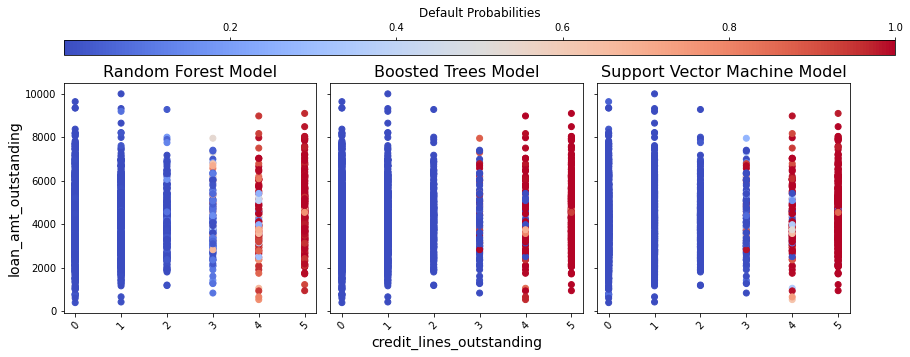

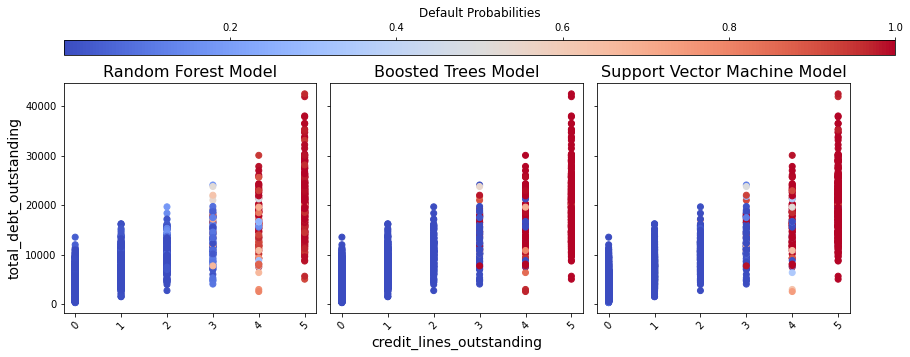

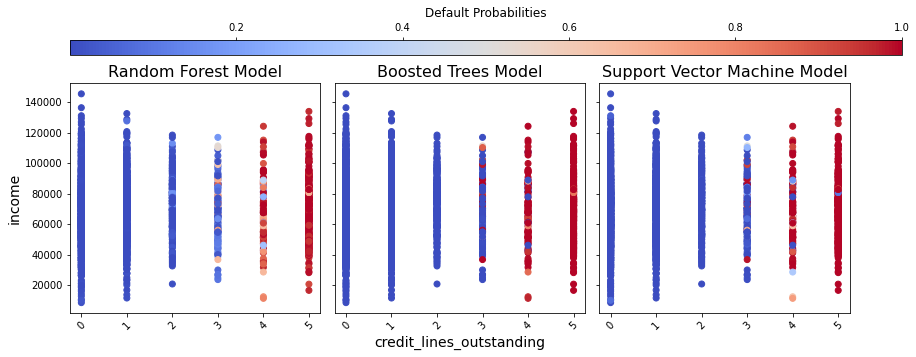

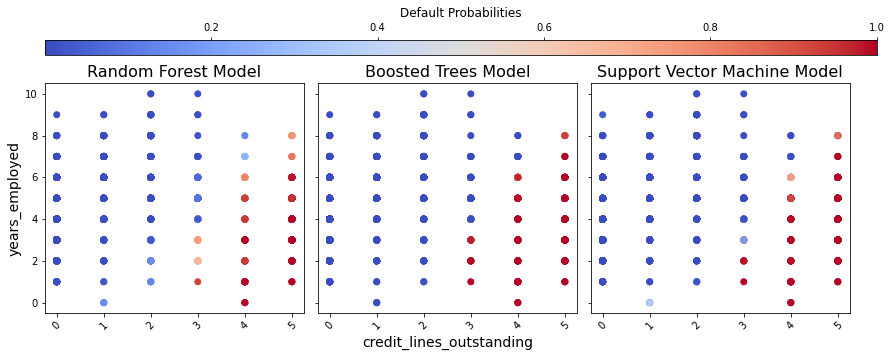

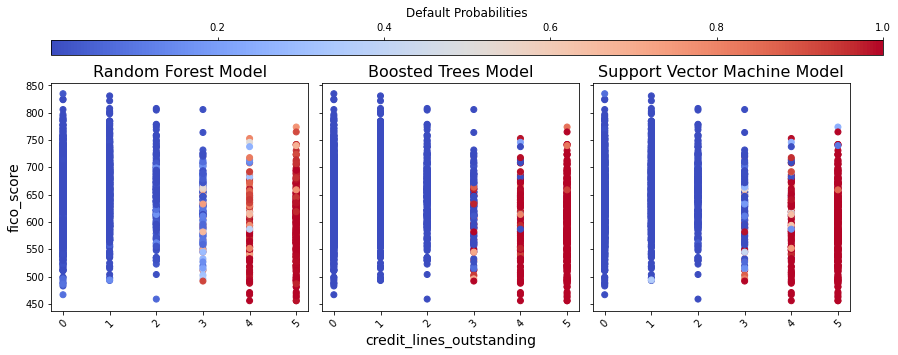

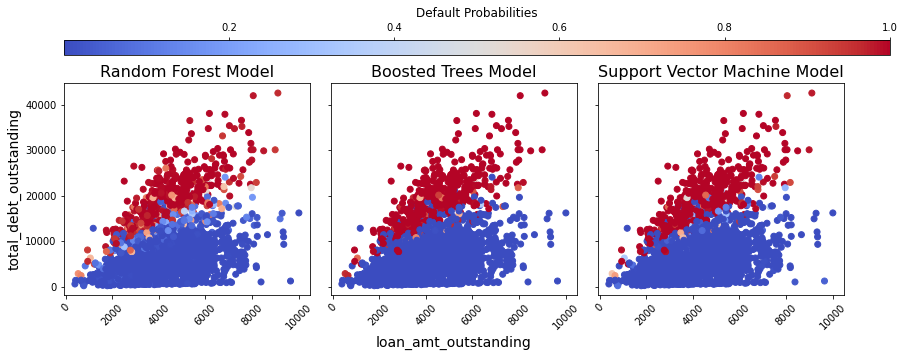

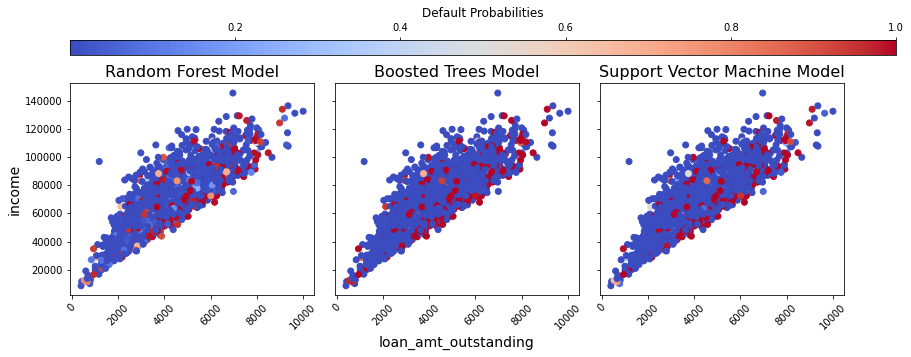

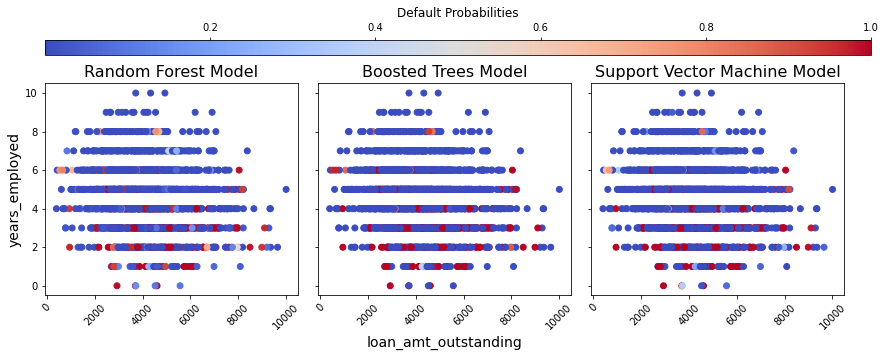

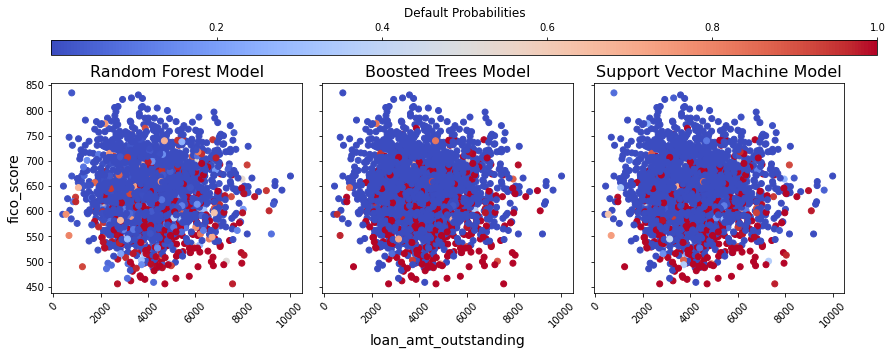

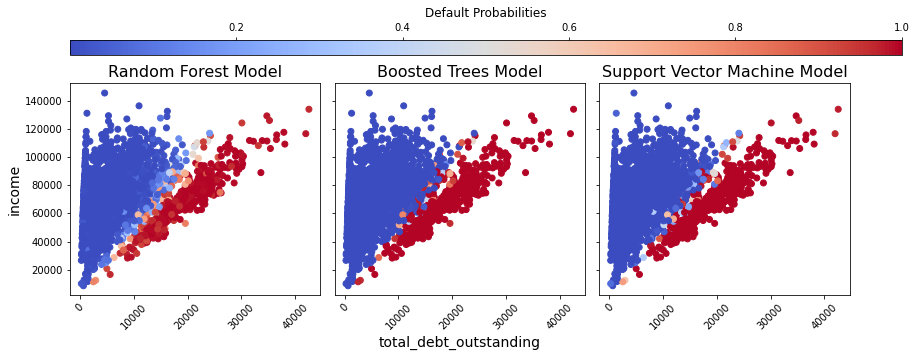

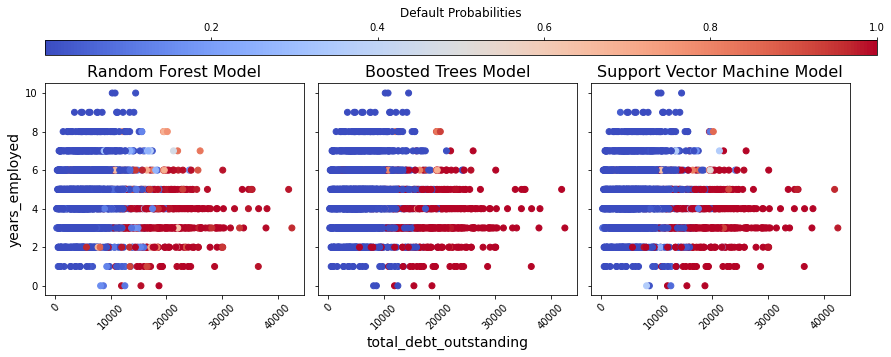

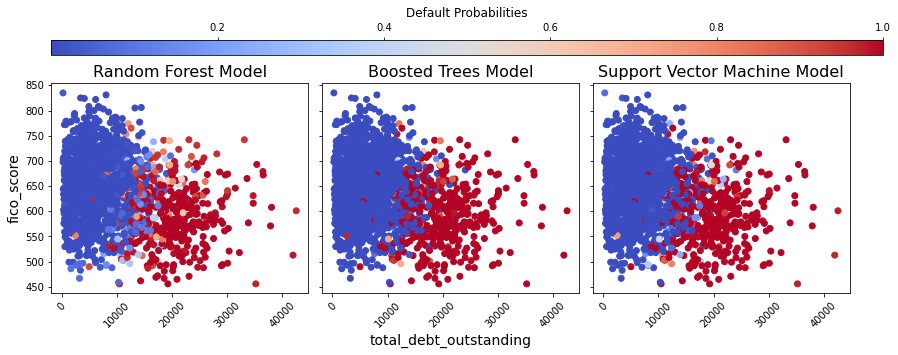

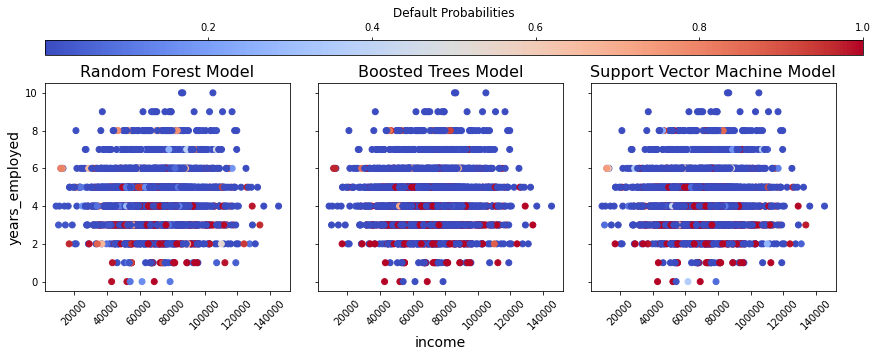

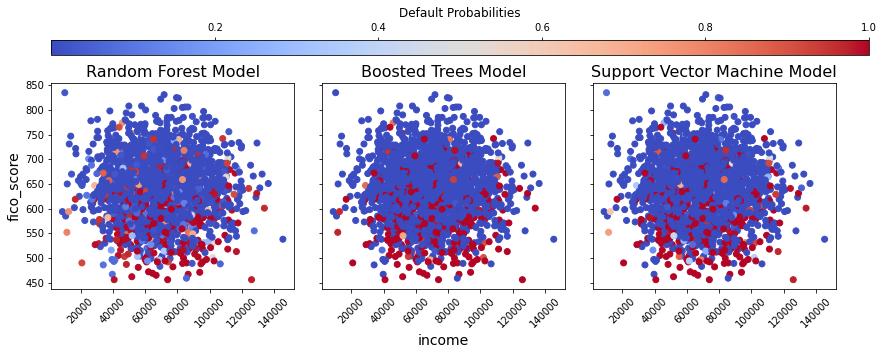

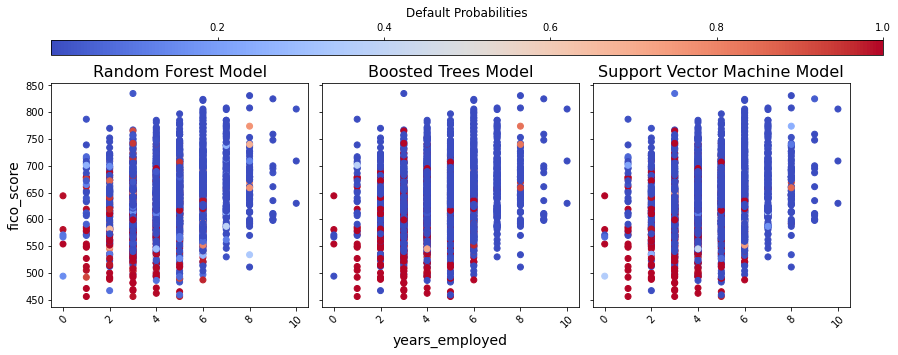

In [14]:
strList = X_valid.columns
loopList = [(strList[i], strList[j]) for i in range(len(strList)) for j in range(i + 1, len(strList))]

for strings in loopList:
    x_str = strings[0]
    y_str = strings[1]

    X = RF_loss[x_str].to_numpy(), BT_loss[x_str].to_numpy(), SVM_loss[x_str].to_numpy()
    Y = RF_loss[y_str].to_numpy(), BT_loss[y_str].to_numpy(), SVM_loss[y_str].to_numpy()
    Z = RF_loss['default_prob'].to_numpy(), BT_loss['default_prob'].to_numpy(), SVM_loss['default_prob'].to_numpy()

    cmap = sns.color_palette("coolwarm", as_cmap=True)
    
    fig, axes = plt.subplots(1,3,figsize=(12,4),sharey=True)
    for i,ax in enumerate(axes):
        im = ax.scatter(X[i],Y[i],c=Z[i],cmap=cmap)
        ax.tick_params(axis='x', labelrotation=45)

    axes[1].set_xlabel(x_str,fontsize=14)
    axes[0].set_ylabel(y_str,fontsize=14)

    fig.tight_layout()
    cax = fig.add_axes([axes[0].get_position().x0, axes[0].get_position().y1+0.1,
                        axes[2].get_position().x1-0.025, 0.05])
    fig.colorbar(im, cax=cax, orientation='horizontal')
    cax.xaxis.set_ticks_position('top')
    cax.set_title('Default Probabilities')

    axes[0].set_title('Random Forest Model',fontsize=16);
    axes[1].set_title('Boosted Trees Model',fontsize=16);
    axes[2].set_title('Support Vector Machine Model',fontsize=16);

    plt.show()


## AND, the expected losses:

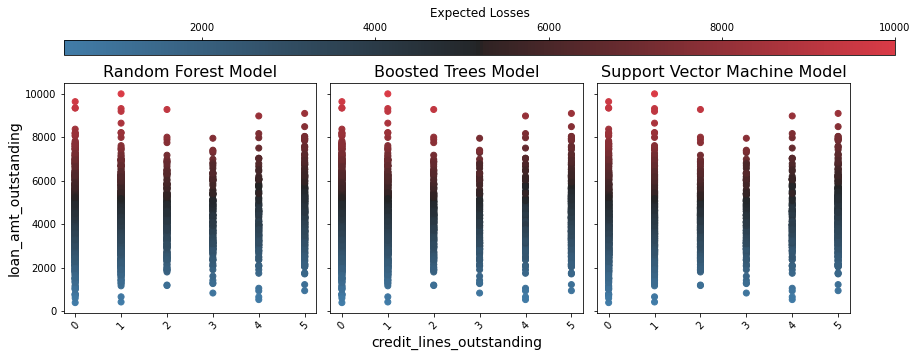

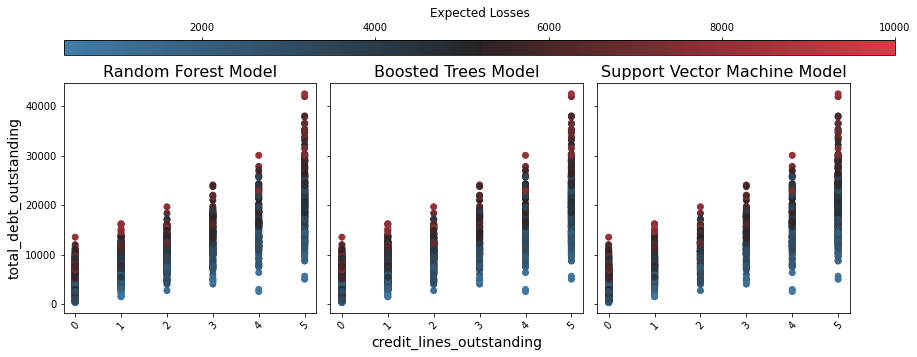

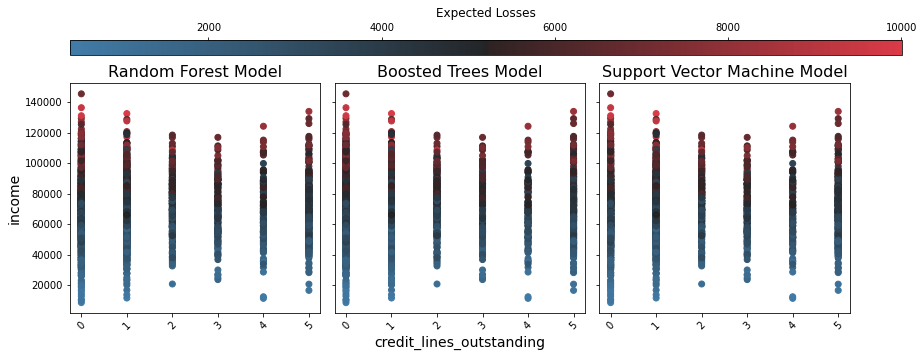

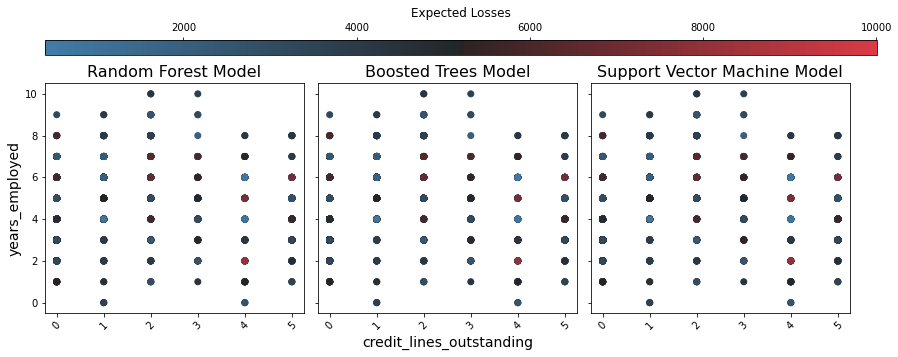

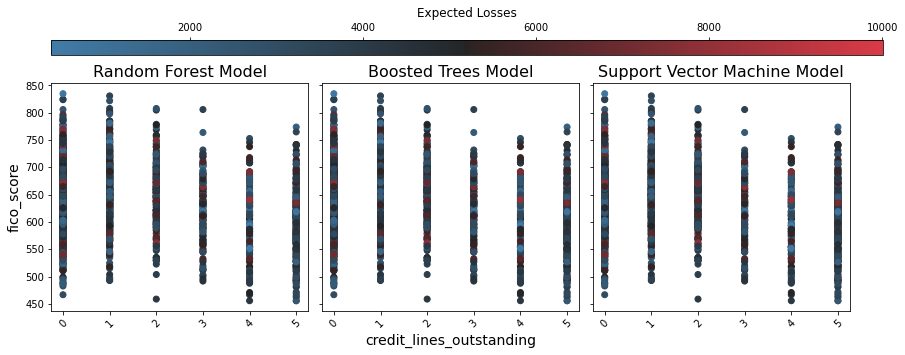

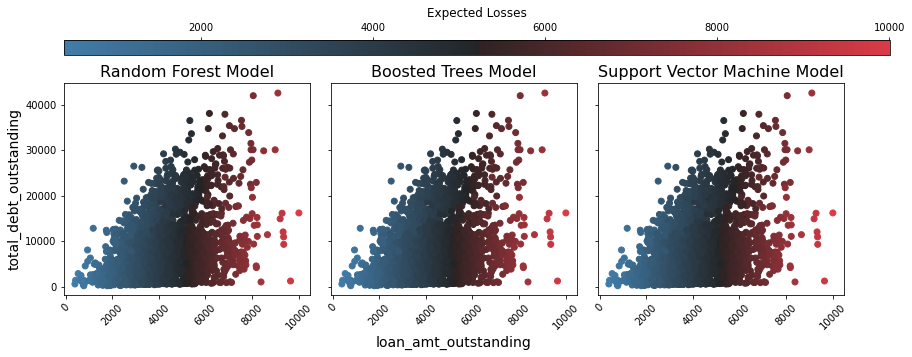

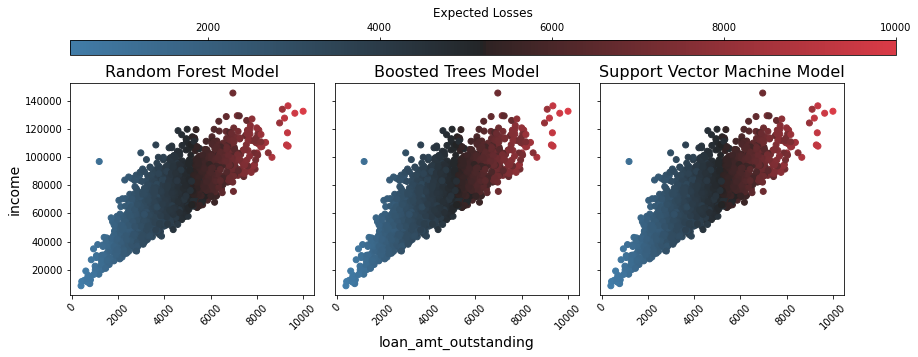

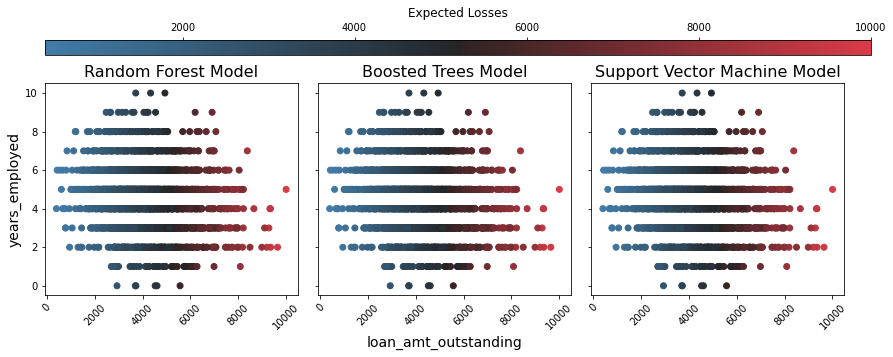

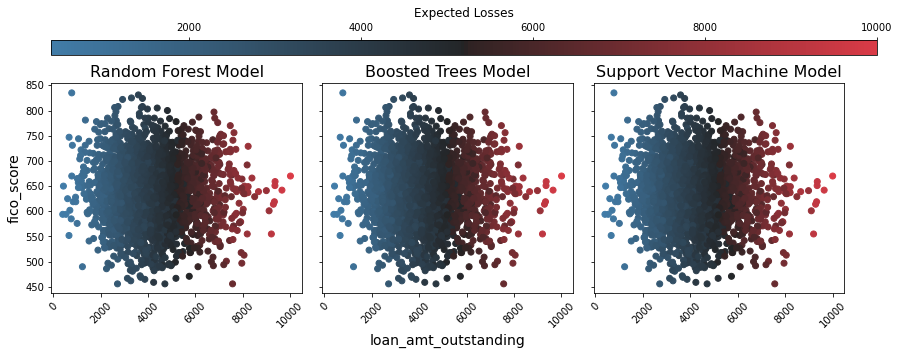

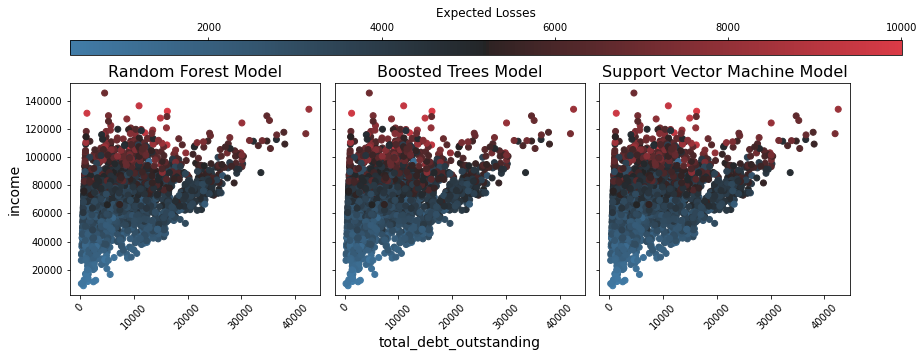

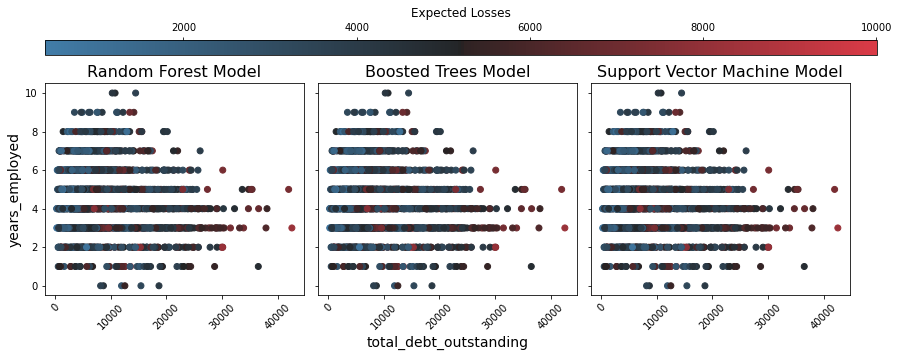

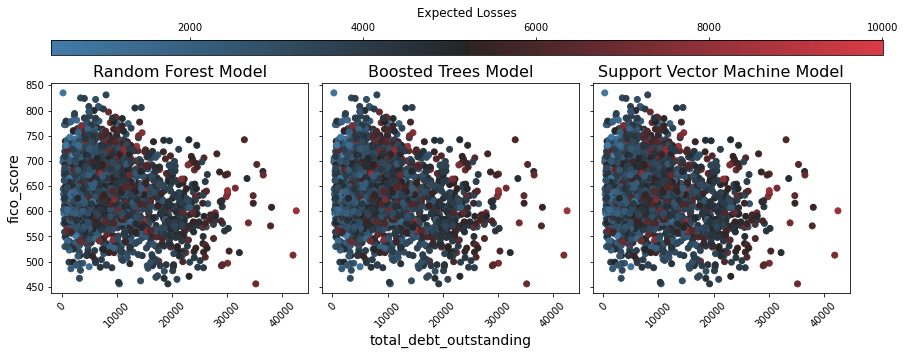

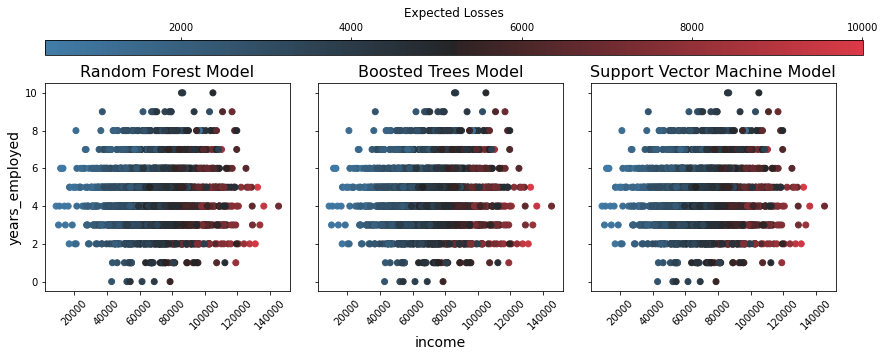

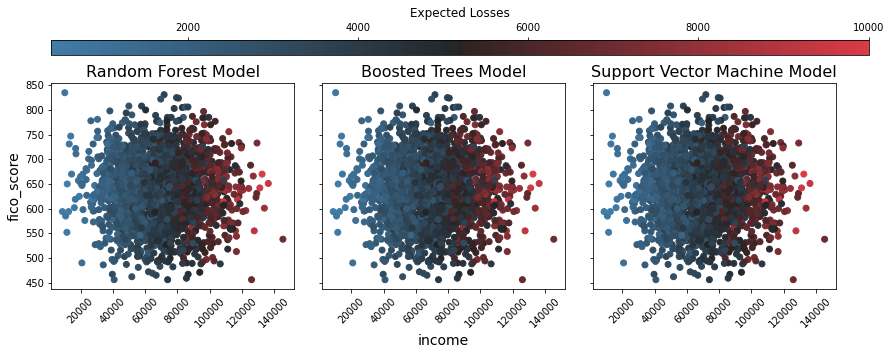

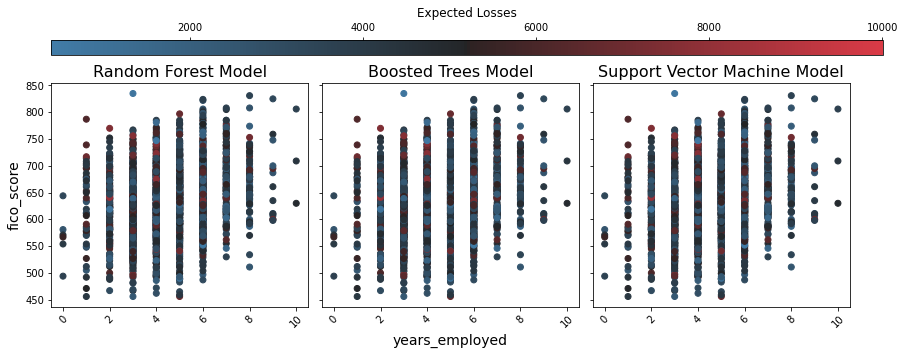

In [19]:
for strings in loopList:
    x_str = strings[0]
    y_str = strings[1]

    X = RF_loss[x_str].to_numpy(), BT_loss[x_str].to_numpy(), SVM_loss[x_str].to_numpy()
    Y = RF_loss[y_str].to_numpy(), BT_loss[y_str].to_numpy(), SVM_loss[y_str].to_numpy()
    Z = ( RF_loss['expected_loss'].to_numpy(), BT_loss['expected_loss'].to_numpy(),
                                    SVM_loss['expected_loss'].to_numpy() )

    cmap = sns.diverging_palette(240, 10, l=50, center="dark", as_cmap=True)
    
    fig, axes = plt.subplots(1,3,figsize=(12,4),sharey=True)
    for i,ax in enumerate(axes):
        im = ax.scatter(X[i],Y[i],c=Z[i],cmap=cmap)
        ax.tick_params(axis='x', labelrotation=45)

    axes[1].set_xlabel(x_str,fontsize=14)
    axes[0].set_ylabel(y_str,fontsize=14)

    fig.tight_layout()
    cax = fig.add_axes([axes[0].get_position().x0, axes[0].get_position().y1+0.1,
                        axes[2].get_position().x1-0.025, 0.05])
    fig.colorbar(im, cax=cax, orientation='horizontal')
    cax.xaxis.set_ticks_position('top')
    cax.set_title('Expected Losses')

    axes[0].set_title('Random Forest Model',fontsize=16);
    axes[1].set_title('Boosted Trees Model',fontsize=16);
    axes[2].set_title('Support Vector Machine Model',fontsize=16);

    plt.show()

So, the probabilities have a more distinct separation than the expected losses, however some relationships are evident. Obviously, the expected losses scale with the outstanding loan amount. More interestingly, the expected losses also scale with income, however after some more thought, one realizes this is simply because loan amount outstanding scales with the borrowers income.